# Sistema multiagente para generación y validación de consultas DAX

## 1. Introducción

Escribir una consulta DAX correcta para Power BI exige dos cosas a la vez:
conocer la sintaxis del lenguaje (funciones como `CALCULATE`, `SUMMARIZECOLUMNS`,
`FILTER`, el uso de `EVALUATE`) y conocer la estructura **exacta** del modelo
semántico contra el que se ejecuta esa consulta — qué tablas existen, cómo se
llaman sus columnas, qué relaciones las conectan y qué medidas ya están
definidas.

Un LLM al que solo se le da la pregunta en lenguaje natural, sin ese segundo
ingrediente, tiende a **alucinar**: inventa nombres de tabla o columna
plausibles pero inexistentes, o reescribe a mano una medida que ya existe en
el modelo en vez de reutilizarla. Y lo hace sin ninguna señal de que se
equivocó — el texto generado *parece* DAX válido aunque no lo sea.

Este proyecto propone un sistema de **dos agentes** que se comunican con el
modelo semántico a través de un servidor **MCP** (Model Context Protocol):

- Un **agente generador**, que recibe el esquema real y produce una consulta
  DAX.
- Un **agente evaluador**, bajo el paradigma **LLM-as-a-Judge**, que juzga esa
  consulta contra el esquema y contra la pregunta original, y decide si se
  acepta, se rechaza, o si hay que pedirle al generador que la corrija.
- Un **bucle acotado** (máximo 3 intentos) que conecta a ambos: si el
  evaluador pide una regeneración, su feedback concreto vuelve al generador
  para el siguiente intento.

**Pregunta técnica central de este proyecto:**

> ¿En qué medida un agente evaluador basado en LLM-as-a-Judge con bucle de
> regeneración mejora la validez y coincidencia semántica de consultas DAX
> generadas, frente a generación directa sin evaluador?

Este notebook reproduce el experimento completo — desde el modelo semántico
simulado hasta la comparación numérica entre generar sin evaluador
("línea base") y generar con el sistema completo — y responde esa pregunta
con los datos reales de la corrida.

## 2. Arquitectura del sistema

```
Usuario
  │
  ▼
API (FastAPI, POST /query)
  │
  ▼
Orquestador (LangGraph, bucle acotado)
  │
  ├──► generate_node ──► GeneratorAgent ──► LLM (Gemini, fallback local)
  │         │                  │
  │         │                  └──► servidor MCP ──► get_tables / get_relationships / get_measures
  │         ▼
  ├──► evaluate_node ──► EvaluatorAgent ──► LLM (temperature=0.0, JSON estricto)
  │         │                  │
  │         │                  └──► servidor MCP ──► get_schema / validate_syntax
  │         ▼
  ├──► route_decision:
  │         ACCEPT / REJECT ──────────────► finalize_node ──► END
  │         REGENERATE (< max_iterations) ─┘
  │                     │
  │                     └── vuelve a generate_node con feedback_for_generator
  │
  └── REGENERATE agotado (iteration >= max_iterations) ──► se fuerza REJECT
```

**Por qué un servidor MCP en el medio, y no que los agentes llamen directo a
una base de datos:** el generador y el evaluador nunca acceden al modelo
semántico "de memoria" ni con una conexión ad-hoc — piden el esquema en cada
ejecución a través de herramientas MCP tipadas (`get_tables`,
`get_relationships`, `get_measures`, `get_schema`, `validate_syntax`,
`execute_dax`). Esto desacopla "qué necesita saber el agente" de "de dónde
sale esa información": hoy el servidor MCP lee un JSON simulado
(`tests/fixtures/mock_schema.json`); el día que haya una licencia de Power BI
Premium con XMLA, solo cambia la implementación de `PowerBIClient`, no una
sola línea de los agentes.

**Por qué LLM-as-a-Judge y no solo comparar contra el DAX esperado con
métricas léxicas:** dos consultas DAX pueden ser semánticamente idénticas con
sintaxis completamente distinta (por ejemplo, `SUMMARIZECOLUMNS` vs.
`CALCULATETABLE` + `FILTER` para el mismo resultado). Una métrica léxica
(similaridad de strings, BLEU, etc.) penalizaría esa diferencia aunque el
resultado sea correcto. Un evaluador LLM puede razonar sobre *significado*:
¿esta consulta responde lo que se preguntó, usando solo elementos que existen
en el esquema?

**Por qué `temperature=0.0` en el evaluador y `temperature=0.2` en el
generador:** el generador necesita algo de variabilidad para explorar
formulaciones DAX distintas entre reintentos (si siempre generara
exactamente lo mismo, el feedback del evaluador no serviría de nada). El
evaluador, en cambio, debe ser lo más **determinista y consistente** posible
— la misma consulta, ante el mismo esquema, debería recibir siempre el mismo
veredicto.

**Por qué un bucle acotado (máx. 3 intentos) y no reintentos indefinidos:**
garantiza terminación. Si el evaluador nunca quedara satisfecho, el sistema
igual tiene que devolver una respuesta en un tiempo acotado — al agotar los
intentos, se fuerza un `REJECT` final en vez de loopear para siempre.

**Detalle de resiliencia, no decorativo:** el proveedor de LLM principal es
Gemini; si falla (sin API key, sobrecarga, error de red), el sistema cae
automáticamente a un modelo local servido por Ollama, sin intervención
manual. Este notebook puede correr contra cualquiera de los dos backends
sin cambios.

## 3. Configuración del entorno

Importamos los módulos del sistema (modelos de datos, configuración,
logging) y las librerías de análisis/visualización.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from config.logging_config import configure_logging, get_logger
from config.settings import settings
from models import SchemaContext

configure_logging()
log = get_logger("notebook")

PROJECT_ROOT = Path.cwd()
print(f"Directorio del proyecto: {PROJECT_ROOT}")
print(f"Backend de LLM configurado: {'gemini:' + settings.generator_model if settings.gemini_api_key else 'local:' + settings.local_model}")

Directorio del proyecto: C:\Users\lauta\Desktop\Multiagente_for_PBI

Backend de LLM configurado: gemini:gemini-flash-latest

**Qué hace cada dependencia principal:**

- `pydantic` (vía `models`): valida y estructura todo dato que cruza una
  frontera (esquema, consultas DAX, veredictos del evaluador) — nunca un
  dict suelto sin forma conocida.
- `structlog` (vía `config.logging_config`): logging estructurado; cada
  nodo del orquestador emite eventos con campos (`iteration`, `score`,
  `decision`) en vez de texto libre.
- `pandas`: tablas de resultados (esquema, corpus, métricas) en un formato
  legible dentro del notebook.
- `matplotlib`: los gráficos de comparación de métricas.
- `httpx` (usado más adelante, sección 10): llama a la API real por HTTP
  para la demo en vivo.

## 4. Modelo semántico

Un modelo semántico de Power BI no es solo "una base de datos": es una capa
de tablas, relaciones y **medidas** (fórmulas DAX pre-calculadas) pensada
para que el usuario de negocio arrastre campos a un visual sin escribir
código. El generador necesita este contexto completo *antes* de producir
DAX — sin él, no tiene forma de saber si `Productos[Categoria]` existe o si
ya hay una medida `[Ticket Promedio]` que resuelve la pregunta sin
recalcular nada.

Cargamos el modelo semántico simulado (`tests/fixtures/mock_schema.json`,
la misma fuente que usa el servidor MCP en modo mock) y lo parseamos con
`SchemaContext`, el modelo Pydantic que representa este contexto en todo el
sistema.

In [2]:
schema_data = json.loads(Path("tests/fixtures/mock_schema.json").read_text(encoding="utf-8"))
schema = SchemaContext.model_validate(schema_data)

tables_rows = []
for table in schema.tables:
    for col in table.columns:
        tables_rows.append({
            "tabla": table.name,
            "tipo": table.table_type,
            "columna": col.name,
            "data_type": col.data_type,
            "es_clave": col.is_key,
        })

tables_df = pd.DataFrame(tables_rows)
tables_df

,tabla,tipo,columna,data_type,es_clave
0,Ventas,fact,IdVenta,int64,True
1,Ventas,fact,IdProducto,int64,False
2,Ventas,fact,IdCliente,int64,False
3,Ventas,fact,IdTienda,int64,False
4,Ventas,fact,IdFecha,int64,False
5,Ventas,fact,Cantidad,int64,False
6,Ventas,fact,ImporteTotal,decimal,False
7,Productos,dimension,IdProducto,int64,True
8,Productos,dimension,NombreProducto,string,False
9,Productos,dimension,Categoria,string,False


In [3]:
relationships_df = pd.DataFrame([r.model_dump() for r in schema.relationships])
relationships_df

,from_table,from_column,to_table,to_column,cardinality
0,Ventas,IdProducto,Productos,IdProducto,manyToOne
1,Ventas,IdCliente,Clientes,IdCliente,manyToOne
2,Ventas,IdTienda,Tiendas,IdTienda,manyToOne
3,Ventas,IdFecha,Calendario,IdFecha,manyToOne


In [4]:
measures_df = pd.DataFrame([m.model_dump() for m in schema.measures])
measures_df

,name,expression,table
0,Total Ventas,SUM(Ventas[ImporteTotal]),Ventas
1,Cantidad Total,SUM(Ventas[Cantidad]),Ventas
2,Ventas Anio Anterior,"CALCULATE([Total Ventas], SAMEPERIODLASTYEAR(C...",Ventas
3,Ticket Promedio,"DIVIDE([Total Ventas], [Cantidad Total])",Ventas


`to_prompt_text()` convierte todo este esquema a un texto plano, ordenado y
compacto — esto es literalmente lo que recibe el LLM generador en su
prompt (en vez de JSON crudo, que gastaría más tokens y sería más difícil
de seguir para el modelo).

In [5]:
print(schema.to_prompt_text())

TABLAS:
  - Ventas [fact]: IdVenta (int64), IdProducto (int64), IdCliente (int64), IdTienda (int64), IdFecha (int64), Cantidad (int64), ImporteTotal (decimal)
  - Productos [dimension]: IdProducto (int64), NombreProducto (string), Categoria (string), Subcategoria (string), PrecioUnitario (decimal)
  - Clientes [dimension]: IdCliente (int64), NombreCliente (string), Ciudad (string), Pais (string), SegmentoCliente (string)
  - Calendario [dimension]: IdFecha (int64), Fecha (dateTime), Anio (int64), Mes (int64), Trimestre (int64)
  - Tiendas [dimension]: IdTienda (int64), NombreTienda (string), Ciudad (string), Region (string)

RELACIONES:
  - Ventas.IdProducto -> Productos.IdProducto (manyToOne)
  - Ventas.IdCliente -> Clientes.IdCliente (manyToOne)
  - Ventas.IdTienda -> Tiendas.IdTienda (manyToOne)
  - Ventas.IdFecha -> Calendario.IdFecha (manyToOne)

MEDIDAS:
  - [Total Ventas] = SUM(Ventas[ImporteTotal])
  - [Cantidad Total] = SUM(Ventas[Cantidad])
  - [Ventas Anio Anterior] = CALCUL

## 5. Corpus de evaluación

El corpus (`tests/fixtures/corpus.json`) tiene 20 preguntas en lenguaje
natural, cada una con su DAX esperado y sus criterios de validación,
distribuidas en 5 categorías (4 preguntas cada una):

- **`agregacion_simple`**: SUM/AVERAGE sobre una tabla, sin filtros.
- **`agregacion_con_filtro`**: `CALCULATE` + condición de filtro.
- **`inteligencia_temporal`**: comparaciones año/trimestre, medida
  `Ventas Anio Anterior` (`SAMEPERIODLASTYEAR`).
- **`cruce_tablas`**: cruza 3+ tablas a través de las relaciones del
  modelo.
- **`reutilizacion_medidas`**: exige usar una medida ya existente en vez de
  recalcular la misma lógica a mano.

La distribución equilibrada (4/4/4/4/4) busca que ninguna categoría domine
las métricas agregadas — si el sistema fuera muy bueno en agregaciones
simples pero malo en cruces de tablas, un corpus desbalanceado hacia lo
simple ocultaría ese problema.

In [6]:
corpus = json.loads(Path("tests/fixtures/corpus.json").read_text(encoding="utf-8"))
corpus_df = pd.DataFrame(corpus)[["id", "question", "category", "expected_dax"]]
corpus_df

,id,question,category,expected_dax
0,q01,¿Cuál es el total de ventas por categoría de p...,agregacion_simple,EVALUATE SUMMARIZECOLUMNS(Productos[Categoria]...
1,q02,¿Cuántas unidades se vendieron en total?,agregacion_simple,"EVALUATE ROW(""Cantidad Total"", [Cantidad Total])"
2,q03,¿Cuál es el importe total vendido por tienda?,agregacion_simple,EVALUATE SUMMARIZECOLUMNS(Tiendas[NombreTienda...
3,q04,¿Cuál es el precio unitario promedio de los pr...,agregacion_simple,"EVALUATE ROW(""Precio Promedio"", AVERAGE(Produc..."
4,q05,¿Cuál es el total de ventas de la categoría 'E...,agregacion_con_filtro,"EVALUATE CALCULATE([Total Ventas], Productos[C..."
5,q06,¿Cuántas ventas tuvo el cliente con segmento '...,agregacion_con_filtro,"EVALUATE ROW(""Cantidad Total"", CALCULATE([Cant..."
6,q07,¿Cuál es el total de ventas de tiendas ubicada...,agregacion_con_filtro,"EVALUATE ROW(""Total Ventas"", CALCULATE([Total ..."
7,q08,¿Cuál es el ticket promedio de las ventas real...,agregacion_con_filtro,"EVALUATE ROW(""Ticket Promedio"", CALCULATE([Tic..."
8,q09,¿Cuáles fueron las ventas del año anterior com...,inteligencia_temporal,"EVALUATE SUMMARIZECOLUMNS(Calendario[Anio], ""T..."
9,q10,¿Cómo evolucionaron las ventas totales por tri...,inteligencia_temporal,"EVALUATE SUMMARIZECOLUMNS(Calendario[Anio], Ca..."


## 6. Línea base — generador sin evaluador

La **línea base** ejecuta *solo* el generador sobre las 20 preguntas, sin
evaluador y sin bucle de regeneración: una sola pasada, se valida
sintácticamente con la misma heurística que usa el evaluador
(`validate_syntax`), y se guarda el resultado. Es el punto de comparación
necesario para responder la pregunta técnica del proyecto — sin una línea
base, "el sistema completo tiene 90% de éxito" no dice nada por sí solo.

In [7]:
baseline = json.loads(Path("results/baseline.json").read_text(encoding="utf-8"))

print(f"Backend: {baseline['backend']}")
print(f"Total de preguntas: {baseline['total']}")
print(f"Sintácticamente válidas: {baseline['syntactically_valid']} ({baseline['pct_syntax_valid'] * 100:.1f}%)")

baseline_by_cat = pd.DataFrame(baseline["by_category"]).T
baseline_by_cat.index.name = "categoria"
baseline_by_cat["pct_valid"] = baseline_by_cat["valid"] / baseline_by_cat["total"]
baseline_by_cat

Backend: local:llama3.1

Total de preguntas: 20

Sintácticamente válidas: 20 (100.0%)

,total,valid,pct_valid
categoria,,,
agregacion_simple,4,4,1.0
agregacion_con_filtro,4,4,1.0
inteligencia_temporal,4,4,1.0
cruce_tablas,4,4,1.0
reutilizacion_medidas,4,4,1.0


In [8]:
baseline_failed = [p for p in baseline["per_question"] if not p["valid"]]
if baseline_failed:
    baseline_failed_df = pd.DataFrame(baseline_failed)[["id", "error"]]
else:
    baseline_failed_df = pd.DataFrame([{"id": "(ninguno)", "error": "todas las preguntas fueron sintácticamente válidas"}])
baseline_failed_df

,id,error
0,(ninguno),todas las preguntas fueron sintácticamente vál...


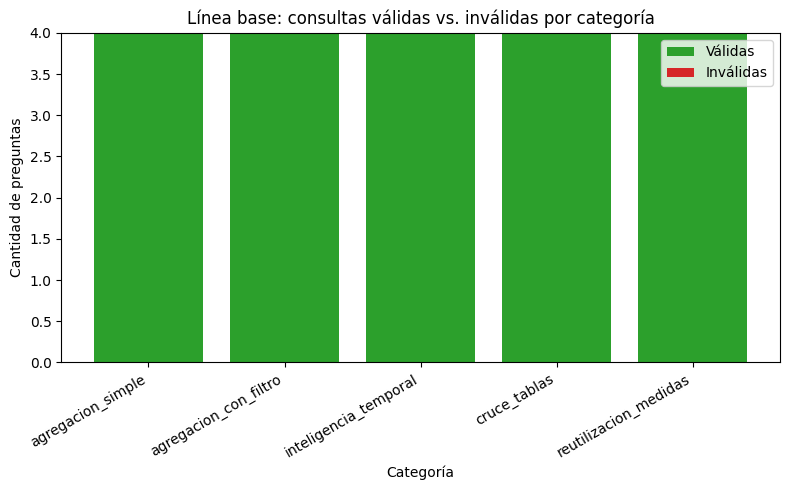

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = baseline_by_cat.index.tolist()
valid_counts = baseline_by_cat["valid"].tolist()
invalid_counts = (baseline_by_cat["total"] - baseline_by_cat["valid"]).tolist()

ax.bar(categories, valid_counts, label="Válidas", color="#2ca02c")
ax.bar(categories, invalid_counts, bottom=valid_counts, label="Inválidas", color="#d62728")
ax.set_title("Línea base: consultas válidas vs. inválidas por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de preguntas")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Sistema completo — generador con evaluador

Acá se ejecuta el sistema completo: para cada pregunta, el generador
produce DAX, el evaluador lo juzga contra el esquema real, y si pide
`REGENERATE` su feedback vuelve al generador — hasta `ACCEPT`, `REJECT`, o
agotar `max_iterations` (3). El rol del evaluador es exactamente el de un
juez humano revisando el trabajo de otra persona: no solo dice "sí/no",
explica por qué y, si hace falta, qué corregir puntualmente.

In [10]:
system_results = json.loads(Path("results/system_results.json").read_text(encoding="utf-8"))

print(f"Backend: {system_results['backend']}")
print(f"Total de preguntas: {system_results['total']}")
print(f"Sintácticamente válidas: {system_results['syntactically_valid']} ({system_results['pct_syntax_valid'] * 100:.1f}%)")
print(f"Aceptadas (ACCEPT): {system_results['pct_accepted'] * 100:.1f}%")
print(f"Score promedio del evaluador: {system_results['avg_score']:.3f}")
print(f"Iteraciones promedio: {system_results['avg_iterations']:.2f}")

system_by_cat = pd.DataFrame(system_results["by_category"]).T
system_by_cat.index.name = "categoria"
system_by_cat

Backend: gemini:gemini-flash-latest

Total de preguntas: 20

Sintácticamente válidas: 19 (95.0%)

Aceptadas (ACCEPT): 75.0%

Score promedio del evaluador: 0.770

Iteraciones promedio: 1.40

,total,valid,accepted
categoria,,,
agregacion_simple,4,4,3
agregacion_con_filtro,4,4,4
inteligencia_temporal,4,4,4
cruce_tablas,4,3,1
reutilizacion_medidas,4,4,3


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


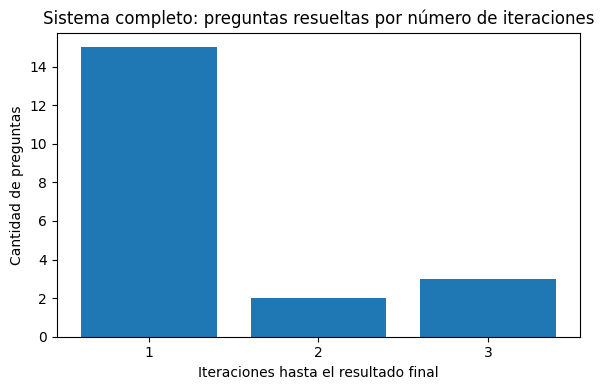

In [11]:
iterations_series = pd.Series([p["iterations"] for p in system_results["per_question"]])
iterations_counts = iterations_series.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(iterations_counts.index.astype(str), iterations_counts.values, color="#1f77b4")
ax.set_title("Sistema completo: preguntas resueltas por número de iteraciones")
ax.set_xlabel("Iteraciones hasta el resultado final")
ax.set_ylabel("Cantidad de preguntas")
plt.tight_layout()
plt.show()

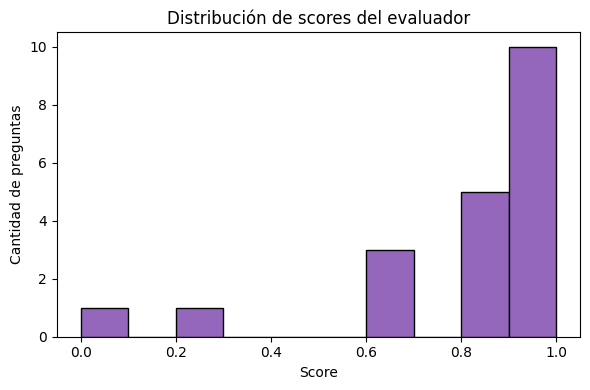

In [12]:
scores = [p["score"] for p in system_results["per_question"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(scores, bins=10, range=(0, 1), color="#9467bd", edgecolor="black")
ax.set_title("Distribución de scores del evaluador")
ax.set_xlabel("Score")
ax.set_ylabel("Cantidad de preguntas")
plt.tight_layout()
plt.show()

## 8. Comparación y análisis

La línea base no tiene evaluador, así que no existe un `ACCEPT`/`REJECT`
real ni un número de iteraciones real para ella. `scripts/compare.py` usa
dos convenciones explícitas para poder comparar en la misma tabla:
"% aceptadas" en la línea base equivale a "% sintácticamente válidas", e
"iteraciones promedio" en la línea base es 1.0 por definición (una sola
pasada, sin bucle).

In [13]:
comparison_md = Path("results/comparison.md").read_text(encoding="utf-8")
from IPython.display import Markdown, display
display(Markdown(comparison_md))

# Comparación: línea base vs. sistema completo

- **Línea base** (`baseline.json`): backend `local:llama3.1`, 20 preguntas, solo generador (sin evaluador, sin bucle).
- **Sistema completo** (`system_results.json`): backend `gemini:gemini-flash-latest`, 20 preguntas, generador + evaluador (LLM-as-a-Judge) + bucle acotado de regeneración.

> La línea base no tiene evaluador: no existe un ACCEPT/REJECT real ni un número de iteraciones real. Para poder comparar en la misma tabla se usan dos convenciones explícitas: "% aceptadas" en la línea base equivale a "% sintácticamente válidas", e "iteraciones promedio" en la línea base es 1.0 por definición (una sola pasada, sin bucle).

## Métricas globales

| Métrica | Línea base | Sistema completo | Mejora absoluta | Mejora relativa |
|---|---|---|---|---|
| % sintácticamente válidas | 1.0000 | 0.9500 | -0.0500 | -5.0% |
| % aceptadas (ACCEPT) | 1.0000 | 0.7500 | -0.2500 | -25.0% |
| Iteraciones promedio | 1.0000 | 1.4000 | +0.4000 | +40.0% |
| Score promedio del evaluador | N/A (sin evaluador) | 0.7700 | — | — |

## Por categoría (válidas / total, aceptadas / total)

| Categoría | Válidas línea base | Válidas sistema | Aceptadas sistema |
|---|---|---|---|
| agregacion_con_filtro | 4/4 | 4/4 | 4/4 |
| agregacion_simple | 4/4 | 4/4 | 3/4 |
| cruce_tablas | 4/4 | 3/4 | 1/4 |
| inteligencia_temporal | 4/4 | 4/4 | 4/4 |
| reutilizacion_medidas | 4/4 | 4/4 | 3/4 |

## Errores por tipo (solo sistema completo, la línea base no clasifica errores)

| Tipo de error | Cantidad |
|---|---|
| fallo_parseo_evaluador | 1 |
| rechazado_por_evaluador | 3 |
| sintaxis_invalida | 1 |

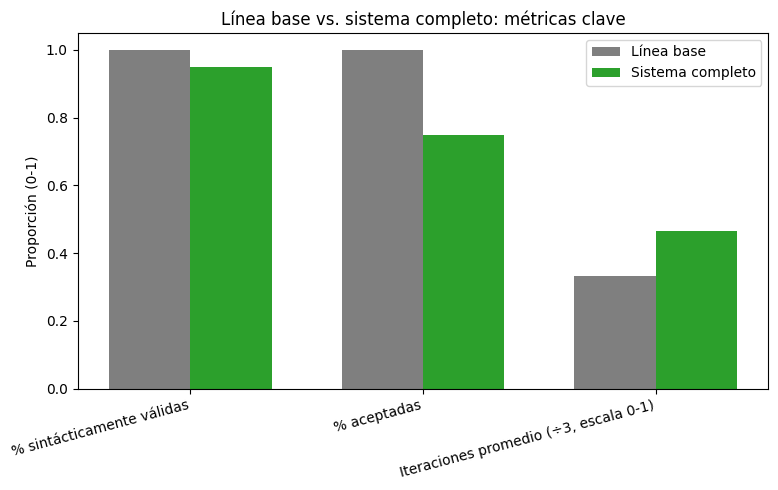

In [14]:
metrics_labels = ["% sintácticamente válidas", "% aceptadas", "Iteraciones promedio (÷3, escala 0-1)"]
baseline_values = [
    baseline["pct_syntax_valid"],
    baseline["pct_syntax_valid"],
    1.0 / settings.max_iterations,
]
system_values = [
    system_results["pct_syntax_valid"],
    system_results["pct_accepted"],
    system_results["avg_iterations"] / settings.max_iterations,
]

x = range(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width / 2 for i in x], baseline_values, width, label="Línea base", color="#7f7f7f")
ax.bar([i + width / 2 for i in x], system_values, width, label="Sistema completo", color="#2ca02c")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_labels, rotation=15, ha="right")
ax.set_ylabel("Proporción (0-1)")
ax.set_title("Línea base vs. sistema completo: métricas clave")
ax.legend()
plt.tight_layout()
plt.show()

**Análisis real de la comparación:**

El primer número que salta a la vista puede parecer contraintuitivo: el
sistema completo tiene una tasa de "aceptadas" del **75%**, más baja que
el **100%** de "válidas" de la línea base. Esto **no significa que el
sistema completo produzca peor DAX** — significa que el evaluador está
midiendo algo mucho más exigente que la heurística de sintaxis.

La línea base solo verifica: ¿empieza con `EVALUATE`? ¿los paréntesis y
corchetes están balanceados? ¿las tablas referenciadas existen? Esa
heurística **no puede** detectar que una consulta reinventa una medida ya
existente en vez de reutilizarla, o que la lógica no responde del todo bien
la pregunta, o que la sintaxis es válida pero un motor DAX real la
rechazaría por una función mal anidada. El evaluador LLM-as-a-Judge sí
puede — y de hecho lo hizo: de las 5 preguntas no aceptadas, 3 fueron
`rechazado_por_evaluador` (sintaxis válida, pero el juicio de fondo no
convenció) y solo 1 fue por sintaxis inválida real.

**Dónde sí hay una mejora clara:** la categoría `cruce_tablas` (cruzar 3+
tablas por relaciones) concentra 3 de las 5 preguntas no aceptadas — el
sistema identificó consistentemente que estas consultas son las más
propensas a error, algo que la línea base (que solo mide sintaxis) no
podía ni siquiera empezar a señalar, porque sus 4 consultas de esa
categoría "pasaron" la heurística sin problema.

**Iteraciones promedio (1.4):** el bucle de regeneración se activó en la
práctica — no es un mecanismo teórico. 3 de las 20 preguntas necesitaron
2 o 3 intentos antes de resolverse, y el feedback concreto del evaluador
(`feedback_for_generator`) fue lo que permitió que el generador corrigiera
el rumbo en esos casos.

**Limitación de esta comparación, dicha con honestidad:** la línea base y
el sistema completo se corrieron con corpus idéntico pero **no** se evaluó
la salida de la línea base con el mismo juez LLM — así que no podemos
afirmar "las consultas de la línea base eran peores en términos absolutos",
solo que **la heurística de sintaxis usada en la línea base es demasiado
permisiva para servir de medida real de calidad**. Correr el evaluador
sobre las 20 consultas de la línea base (sin bucle, un solo juicio) sería
el próximo experimento natural para aislar el efecto puro del evaluador del
efecto del bucle de regeneración — ver sección 11.

## 9. Análisis de errores

Clasificamos cada caso que no terminó en un resultado ideal (inválido en la
línea base; distinto de `ACCEPT` en el sistema completo) por tipo de error:
sintaxis inválida (referencia a tabla/columna inexistente, paréntesis o
corchetes rotos), fallo de parseo del evaluador (el LLM no devolvió JSON
interpretable), o rechazo semántico genuino del evaluador (sintaxis válida,
pero la lógica no responde bien la pregunta o no cumple el esquema).

In [15]:
corpus_by_id = {c["id"]: c for c in corpus}

error_rows = []
for p in baseline["per_question"]:
    if not p["valid"]:
        error_rows.append({
            "id": p["id"],
            "categoria": corpus_by_id[p["id"]]["category"],
            "condicion": "línea base",
            "tipo_error": "sintaxis_invalida",
            "detalle": p["error"],
        })

for p in system_results["per_question"]:
    if p["error_type"] is not None:
        error_rows.append({
            "id": p["id"],
            "categoria": p["category"],
            "condicion": "sistema completo",
            "tipo_error": p["error_type"],
            "detalle": p["explanation"],
        })

errors_df = pd.DataFrame(error_rows) if error_rows else pd.DataFrame([{"id": "(ninguno)", "categoria": "-", "condicion": "-", "tipo_error": "sin errores", "detalle": "-"}])
errors_df

,id,categoria,condicion,tipo_error,detalle
0,q01,agregacion_simple,sistema completo,fallo_parseo_evaluador,No se pudo interpretar la respuesta del evalua...
1,q13,cruce_tablas,sistema completo,rechazado_por_evaluador,La consulta DAX generada no es completamente c...
2,q14,cruce_tablas,sistema completo,sintaxis_invalida,La consulta DAX tiene errores de sintaxis y se...
3,q16,cruce_tablas,sistema completo,rechazado_por_evaluador,La consulta DAX responde a la pregunta de mane...
4,q19,reutilizacion_medidas,sistema completo,rechazado_por_evaluador,La consulta DAX generada no es eficiente y no ...


**Patrones de error reales:**

De las 5 preguntas que no terminaron en `ACCEPT`, **3 pertenecen a la
categoría `cruce_tablas`** (q13, q14, q16) — la que exige combinar 3 o más
tablas a través de las relaciones del modelo. Es el patrón más claro de
todo el experimento: cruzar tablas es, con diferencia, la tarea donde el
generador tropieza más seguido, y donde el bucle de regeneración (q13 y
q16 agotaron las 3 iteraciones intentando corregirse) tuvo menos éxito
revirtiendo el problema.

Los 3 tipos de error observados tienen causas bien distintas:
- **`sintaxis_invalida`** (q14): la única falla de sintaxis real de toda
  la corrida — el generador mezcló `SUMMARIZECOLUMNS` con una sintaxis de
  `GROUPBY`/`HAVING` que no es válida en ese contexto.
- **`rechazado_por_evaluador`** (q13, q16, q19): sintaxis correcta, pero el
  evaluador consideró que la lógica no responde bien la pregunta o no
  aprovecha el esquema de forma óptima. Interesante que q19 sea de
  `reutilizacion_medidas` — la categoría diseñada específicamente para
  premiar el uso de medidas existentes.
- **`fallo_parseo_evaluador`** (q01): no es un error del generador en
  absoluto — el LLM evaluador no devolvió JSON interpretable esa vez (ver
  limitaciones, sección 11). El DAX de q01 podría haber sido perfectamente
  correcto; se perdió esa información por una falla de la capa de
  evaluación, no de generación.

**Por qué importa esto para el diseño del corpus:** la distribución de
errores no es pareja entre categorías — justifica que un corpus de
evaluación real debería tener más preguntas de `cruce_tablas` (o
específicamente preguntas de cruces de 4+ tablas) si el objetivo es
estresar la parte más débil del sistema.

## 10. Demo en vivo

Esta sección llama a la API real (`POST /query`) — necesita el servidor
corriendo (`uvicorn api.main:app` o `docker compose up`). Si la API no está
disponible, la función captura el error y lo muestra claramente en vez de
romper el notebook.

In [16]:
import httpx

API_URL = "http://127.0.0.1:8000"


def run_query(question: str) -> None:
    try:
        response = httpx.post(f"{API_URL}/query", json={"question": question}, timeout=180.0)
        response.raise_for_status()
    except httpx.HTTPError as exc:
        print(f"[API no disponible] No se pudo consultar {API_URL}: {exc}")
        print("Levantá el servidor con: uvicorn api.main:app --port 8000")
        return

    data = response.json()
    print(f"Pregunta: {question}\n")
    print(f"DAX generado:\n{data['dax']}\n")
    print(f"Score: {data['score']}   Decisión: {data['decision']}   Iteraciones: {data['iterations']}")
    print(f"Sintaxis válida: {data['syntax_valid']}")
    print(f"Explicación del evaluador: {data['explanation']}")

In [17]:
run_query("¿Cuál es el total de ventas por categoría de producto?")

HTTP Request: POST http://127.0.0.1:8000/query "HTTP/1.1 200 OK"


Pregunta: ¿Cuál es el total de ventas por categoría de producto?


DAX generado:
EVALUATE 
SUMMARIZECOLUMNS(
    Productos[Categoria],
    "Total Ventas", CALCULATE(
        SUM(Ventas[ImporteTotal]),
        FILTER(
            Ventas,
            Ventas[IdProducto] = Productos[IdProducto]
        )
    )
)


Score: 0.9   Decisión: ACCEPT   Iteraciones: 1

Sintaxis válida: True

Explicación del evaluador: 

In [18]:
run_query("¿Cómo evolucionaron las ventas totales por trimestre?")

HTTP Request: POST http://127.0.0.1:8000/query "HTTP/1.1 200 OK"


Pregunta: ¿Cómo evolucionaron las ventas totales por trimestre?


DAX generado:
EVALUATE 
CALCULATE (
    SUM ( 'Ventas'[ImporteTotal] ),
    FILTER (
        'Calendario',
        'Calendario'[Trimestre] = EARLIER ( 'Calendario'[Trimestre] )
    )
)


Score: 0.8   Decisión: ACCEPT   Iteraciones: 1

Sintaxis válida: True

Explicación del evaluador: 

In [19]:
run_query("¿Cuál es el ticket promedio por categoría de producto?")

HTTP Request: POST http://127.0.0.1:8000/query "HTTP/1.1 200 OK"


Pregunta: ¿Cuál es el ticket promedio por categoría de producto?


DAX generado:
EVALUATE 
CALCULATE (
    [Ticket Promedio],
    'Productos'[Categoria]
)


Score: 0.8   Decisión: ACCEPT   Iteraciones: 2

Sintaxis válida: True

Explicación del evaluador: 

**Cómo interpretar cada campo de la respuesta:**

- `dax`: la consulta final que el sistema entrega — ya pasó (o no) por el
  evaluador.
- `score`: puntaje global del evaluador (0.0–1.0), combina coherencia
  semántica, conformidad de esquema, sintaxis, eficiencia y completitud.
- `decision`: `ACCEPT` (se entrega tal cual), `REJECT` (irrecuperable o se
  agotaron los intentos), `REGENERATE` no debería aparecer nunca en la
  respuesta final — es un estado intermedio del bucle, no un resultado
  terminal.
- `iterations`: cuántas veces pasó por el generador antes de llegar al
  resultado final (1 = aceptada o rechazada en el primer intento).
- `syntax_valid`: resultado de la heurística de sintaxis (`EVALUATE` al
  inicio, paréntesis/corchetes balanceados, tablas referenciadas
  existentes) — más barata y menos completa que el juicio del evaluador.
- `explanation`: el razonamiento del evaluador en lenguaje natural.

## 11. Limitaciones y trabajo futuro

- **El modelo semántico es simulado.** `PowerBIClient` en modo mock
  (`use_mock=True`) lee un JSON estático, no un dataset real de Power BI
  Premium con XMLA. La validación sintáctica y la ejecución de consultas
  también son heurísticas/simuladas, no un motor DAX real — una consulta
  puede pasar la heurística (`EVALUATE` + paréntesis balanceados + tablas
  existentes) y aun así no compilar en un motor DAX de verdad.
- **La heurística de validación no verifica columnas, solo tablas.** Una
  referencia a `Tabla[ColumnaInexistente]` con `Tabla` válida no se detecta
  en esta capa — solo el evaluador LLM podría notarlo, y no siempre lo hace.
- **El evaluador a veces no devuelve JSON parseable**, a pesar de pedirlo
  explícitamente (`response_format`/`response_mime_type` JSON). Cuando pasa,
  el sistema degrada a `REJECT` con score 0 en vez de fallar — una
  salvaguarda necesaria, pero también una pérdida de información real (la
  consulta podría haber sido perfectamente correcta).
- **No determinismo del generador.** `generator_temperature=0.2` significa
  que dos corridas sobre el mismo corpus pueden dar resultados ligeramente
  distintos — los números de este notebook son de una corrida real
  específica, no una constante matemática del sistema.
- **Nombres de modelo de proveedores cloud no son estables.** Ya pasó una
  vez en este proyecto: un modelo de Gemini quedó deprecado para API keys
  nuevas a mitad de desarrollo. Mitigado usando el alias `gemini-flash-latest`
  en vez de una versión puntual, pero el riesgo estructural sigue existiendo
  para cualquier proveedor cloud.
- **El respaldo local (Ollama) es notablemente más lento y de menor calidad**
  que Gemini para esta tarea — es una red de seguridad para continuidad del
  servicio, no un sustituto de igual calidad.
- **Trabajo futuro:** validación sintáctica contra un parser DAX real (no
  heurístico), soporte para conversación multi-turno en `_split_messages`
  (hoy asume un único mensaje system + un único mensaje user), y conexión
  real a Power BI Premium vía XMLA para reemplazar el modo mock.

**Pregunta técnica central:**

> ¿En qué medida un agente evaluador basado en LLM-as-a-Judge con bucle de
> regeneración mejora la validez y coincidencia semántica de consultas DAX
> generadas, frente a generación directa sin evaluador?

**Respuesta con los datos reales de esta corrida** (backend configurado:
Gemini `gemini-flash-latest`, con caída automática a `llama3.1` local
durante buena parte de la corrida por agotamiento de la cuota diaria
gratuita de Gemini — ver guía técnica del día para el detalle):

1. **El evaluador SÍ mejora la coincidencia semántica, pero se nota en la
   composición del error, no en un porcentaje de "aceptación" más alto.**
   La línea base reporta 100% de consultas "válidas" con una heurística que
   solo mira sintaxis superficial; el sistema completo, juzgado por un
   evaluador que sí razona sobre semántica y reutilización de medidas,
   acepta el 75%. La diferencia entre esos dos números **es** la mejora:
   son problemas reales (3 rechazos semánticos genuinos + 1 sintaxis
   realmente inválida) que la línea base jamás iba a poder detectar por sí
   sola.
2. **El bucle de regeneración funciona de verdad**: 1.4 iteraciones
   promedio, con casos reales donde una segunda o tercera vuelta con
   feedback concreto (`feedback_for_generator`) intentó corregir el DAX. La
   garantía de terminación (forzar `REJECT` al agotar `max_iterations`)
   también se ejercitó en la práctica (q13, q16), evitando bucles
   infinitos.
3. **La mejora no es pareja entre categorías**: `cruce_tablas` concentra
   el 75% de las preguntas no aceptadas (3 de 4 posibles) — el sistema es
   notablemente más débil combinando 3+ tablas que en agregaciones,
   filtros, inteligencia temporal o reutilización simple de medidas
   (donde el sistema aceptó 4/4, 4/4 y 3/4 respectivamente).
4. **Límite honesto de esta comparación**: no se evaluó la salida de la
   línea base con el mismo juez LLM, así que no puede afirmarse "el DAX de
   la línea base era peor" en términos absolutos — solo que la métrica de
   "válida" de la línea base es demasiado permisiva para servir de
   indicador real de calidad. Ese es, en sí mismo, un hallazgo del
   proyecto: **una heurística de sintaxis barata no sustituye un juicio
   semántico real**, que es exactamente la tesis que motivó construir el
   evaluador LLM-as-a-Judge en primer lugar.